# Mouse Brain 5k Extraction Scaffold

This notebook is scaffolded for the local Xenium Prime output at:

`/Users/chrislangseth/Downloads/Xenium_Prime_Mouse_Brain_Coronal_FF_xe_outs`

It loads the zipped Zarr payloads directly, builds an `AnnData` object, joins cell-level metadata and spatial coordinates, and writes extraction-friendly outputs before any optional downstream clustering.


## 1) Imports and environment defaults


In [1]:
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

warnings.filterwarnings("ignore")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import zarr

from scipy.sparse import csc_matrix, csr_matrix, issparse
from zarr.storage import ZipStore

ad.settings.allow_write_nullable_strings = True
sc.settings.verbosity = 2
sc.set_figure_params(dpi=110, facecolor="white")


Matplotlib is building the font cache; this may take a moment.


## 2) Configure input and output paths


In [2]:
DATASET_NAME = "mouseBrain5k"
SAMPLE_ID = "mouse_brain_coronal_5k"

INPUT_DIR = Path("/Users/chrislangseth/Downloads/Xenium_Prime_Mouse_Brain_Coronal_FF_xe_outs")
OUTPUT_DIR = Path("/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k")

EXPERIMENT_PATH = INPUT_DIR / "experiment.xenium"
GENE_PANEL_PATH = INPUT_DIR / "gene_panel.json"
MATRIX_ZIP_PATH = INPUT_DIR / "cell_feature_matrix.zarr.zip"
CELLS_ZIP_PATH = INPUT_DIR / "cells.zarr.zip"
ANALYSIS_ZIP_PATH = INPUT_DIR / "analysis.zarr.zip"
TRANSCRIPTS_ZIP_PATH = INPUT_DIR / "transcripts.zarr.zip"

RAW_H5AD_PATH = OUTPUT_DIR / f"{DATASET_NAME}_raw.h5ad"
PROCESSED_H5AD_PATH = OUTPUT_DIR / f"{DATASET_NAME}_processed.h5ad"
CELL_METADATA_PATH = OUTPUT_DIR / f"{DATASET_NAME}_cell_metadata.csv.gz"
FEATURE_TABLE_PATH = OUTPUT_DIR / f"{DATASET_NAME}_features.csv.gz"
QC_SUMMARY_PATH = OUTPUT_DIR / f"{DATASET_NAME}_qc_summary.csv"
MARKERS_PATH = OUTPUT_DIR / f"{DATASET_NAME}_markers_leiden_1.0.csv"

MIN_COUNTS = 15
MIN_GENES = 5
TARGET_SUM = 100
N_NEIGHBORS = 15
N_PCS = 30
LEIDEN_RESOLUTIONS = [0.1, 0.5, 1.0]

print("INPUT_DIR:", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


INPUT_DIR: /Users/chrislangseth/Downloads/Xenium_Prime_Mouse_Brain_Coronal_FF_xe_outs
OUTPUT_DIR: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k


## 3) Confirm required files and inspect experiment metadata


In [3]:
required_files = {
    "experiment": EXPERIMENT_PATH,
    "gene_panel": GENE_PANEL_PATH,
    "matrix_zarr": MATRIX_ZIP_PATH,
    "cells_zarr": CELLS_ZIP_PATH,
}

missing = [name for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required input files: {missing}")

with open(EXPERIMENT_PATH) as f:
    experiment_meta = json.load(f)

pd.Series(
    {
        "run_name": experiment_meta.get("run_name"),
        "region_name": experiment_meta.get("region_name"),
        "panel_name": experiment_meta.get("panel_name"),
        "panel_design_id": experiment_meta.get("panel_design_id"),
        "num_cells": experiment_meta.get("num_cells"),
        "transcripts_per_cell": experiment_meta.get("transcripts_per_cell"),
        "analysis_sw_version": experiment_meta.get("analysis_sw_version"),
        "chemistry_version": experiment_meta.get("chemistry_version"),
    }
)


run_name                     Mouse FF Brain Hemisphere (Coronal) 5K
region_name                     Mouse FF Brain Hemisphere (Coronal)
panel_name              Xenium Mouse 5K Pan Tissue & Pathways Panel
panel_design_id                                           mAtlas_v1
num_cells                                                     63173
transcripts_per_cell                                           1088
analysis_sw_version                                 xenium-3.0.0.15
chemistry_version                                                v2
dtype: object

## 4) Helper functions for zipped Xenium Zarr stores


In [4]:
def read_xenium_matrix_zarr(matrix_zip_path: Path) -> ad.AnnData:
    with ZipStore(matrix_zip_path, mode="r") as store:
        root = zarr.open_group(store=store, mode="r")
        cf = root["cell_features"]
        attrs = dict(cf.attrs)

        n_cells = int(attrs["number_cells"])
        n_features = int(attrs["number_features"])

        data = cf["data"][:]
        indices = cf["indices"][:]
        indptr = cf["indptr"][:]

        X = csc_matrix((data, indices, indptr), shape=(n_cells, n_features)).tocsr()

        var = pd.DataFrame(
            {
                "feature_id": attrs["feature_ids"],
                "feature_type": attrs["feature_types"],
            },
            index=pd.Index(attrs["feature_keys"], name="feature_name"),
        )

        cell_ids = cf["cell_id"][:, 0].astype(np.int64).astype(str)
        obs = pd.DataFrame(index=pd.Index(cell_ids, name="cell_id"))

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.var_names_make_unique()
    return adata


def read_xenium_cell_summary(cells_zip_path: Path) -> pd.DataFrame:
    with ZipStore(cells_zip_path, mode="r") as store:
        root = zarr.open_group(store=store, mode="r")

        cell_ids = root["cell_id"][:, 0].astype(np.int64).astype(str)
        cell_summary = root["cell_summary"][:]
        summary_cols = list(root["cell_summary"].attrs["column_names"])

    obs_extra = pd.DataFrame(
        cell_summary,
        columns=summary_cols,
        index=pd.Index(cell_ids, name="cell_id"),
    )
    return obs_extra


def ensure_csr_layers(adata: ad.AnnData) -> None:
    for key, layer in list(adata.layers.items()):
        if not issparse(layer):
            adata.layers[key] = csr_matrix(layer)


## 5) Load the Xenium cell-feature matrix


In [5]:
adata = read_xenium_matrix_zarr(MATRIX_ZIP_PATH)
print(adata)
adata.var["feature_type"].value_counts(dropna=False)


AnnData object with n_obs × n_vars = 63173 × 13781
    var: 'feature_id', 'feature_type'


feature_type
unassigned_codeword          8096
gene                         5006
negative_control_codeword     609
negative_control_probe         40
genomic_control                21
deprecated_codeword             8
aggregate_gene                  1
Name: count, dtype: int64

## 6) Join cell-level metadata and store spatial coordinates


In [6]:
obs_extra = read_xenium_cell_summary(CELLS_ZIP_PATH)

shared_ids = adata.obs_names[adata.obs_names.isin(obs_extra.index)]
if len(shared_ids) == 0:
    raise ValueError("No shared cell IDs found between the matrix archive and cells.zarr.zip")

if len(shared_ids) != adata.n_obs:
    print(f"Restricting to {len(shared_ids):,} shared cells out of {adata.n_obs:,}")

adata = adata[shared_ids].copy()
adata.obs = adata.obs.join(obs_extra, how="left")

gene_mask = adata.var["feature_type"].eq("gene")
adata = adata[:, gene_mask].copy()

adata.obs["sample_id"] = SAMPLE_ID
adata.obs["run_name"] = experiment_meta.get("run_name", SAMPLE_ID)
adata.obs["region_name"] = experiment_meta.get("region_name")
adata.obs["cell_id"] = adata.obs_names.astype(str)

if {"cell_centroid_x", "cell_centroid_y"}.issubset(adata.obs.columns):
    adata.obsm["spatial"] = adata.obs[["cell_centroid_x", "cell_centroid_y"]].to_numpy()

adata.layers["counts"] = adata.X.copy()
ensure_csr_layers(adata)

adata.uns["xenium_source"] = {
    "input_dir": str(INPUT_DIR),
    "matrix_zarr": str(MATRIX_ZIP_PATH),
    "cells_zarr": str(CELLS_ZIP_PATH),
    "analysis_zarr": str(ANALYSIS_ZIP_PATH),
    "transcripts_zarr": str(TRANSCRIPTS_ZIP_PATH),
}
adata.uns["xenium_experiment"] = experiment_meta

print(adata)
adata.obs[[c for c in ["sample_id", "run_name", "cell_centroid_x", "cell_centroid_y", "cell_area", "nucleus_area", "nucleus_count"] if c in adata.obs.columns]].head()


AnnData object with n_obs × n_vars = 63173 × 5006
    obs: 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'sample_id', 'run_name', 'region_name', 'cell_id'
    var: 'feature_id', 'feature_type'
    uns: 'xenium_source', 'xenium_experiment'
    obsm: 'spatial'
    layers: 'counts'


,sample_id,run_name,cell_centroid_x,cell_centroid_y,cell_area,nucleus_area,nucleus_count
cell_id,,,,,,,
45075,mouse_brain_coronal_5k,Mouse FF Brain Hemisphere (Coronal) 5K,610.889465,1741.865845,49.626721,33.099532,1.0
77175,mouse_brain_coronal_5k,Mouse FF Brain Hemisphere (Coronal) 5K,622.179077,1794.472900,55.226096,38.427970,1.0
187535,mouse_brain_coronal_5k,Mouse FF Brain Hemisphere (Coronal) 5K,615.411621,1798.880859,85.796878,75.456096,1.0
232071,mouse_brain_coronal_5k,Mouse FF Brain Hemisphere (Coronal) 5K,613.914185,1845.295044,94.060472,52.290939,1.0
298314,mouse_brain_coronal_5k,Mouse FF Brain Hemisphere (Coronal) 5K,739.221436,3268.997070,112.258442,NaN,0.0


## 7) Inspect the extracted object


In [7]:
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))
print("layers:", list(adata.layers.keys()))
print("obsm keys:", list(adata.obsm.keys()))


obs columns: ['cell_centroid_x', 'cell_centroid_y', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'sample_id', 'run_name', 'region_name', 'cell_id']
var columns: ['feature_id', 'feature_type']
layers: ['counts']
obsm keys: ['spatial']


## 8) QC metrics and per-sample summary


In [8]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

qc_summary = (
    adata.obs.groupby("sample_id")
    .agg(
        n_cells=("cell_id", "count"),
        mean_total_counts=("total_counts", "mean"),
        median_total_counts=("total_counts", "median"),
        mean_genes=("n_genes_by_counts", "mean"),
        median_genes=("n_genes_by_counts", "median"),
        mean_cell_area=("cell_area", "mean"),
        mean_nucleus_area=("nucleus_area", "mean"),
    )
    .sort_values("n_cells", ascending=False)
)

qc_summary


,n_cells,mean_total_counts,median_total_counts,mean_genes,median_genes,mean_cell_area,mean_nucleus_area
sample_id,,,,,,,
mouse_brain_coronal_5k,63173,1369.662387,1088.0,696.417599,656.0,90.227111,45.133729


## 9) Quick QC plots


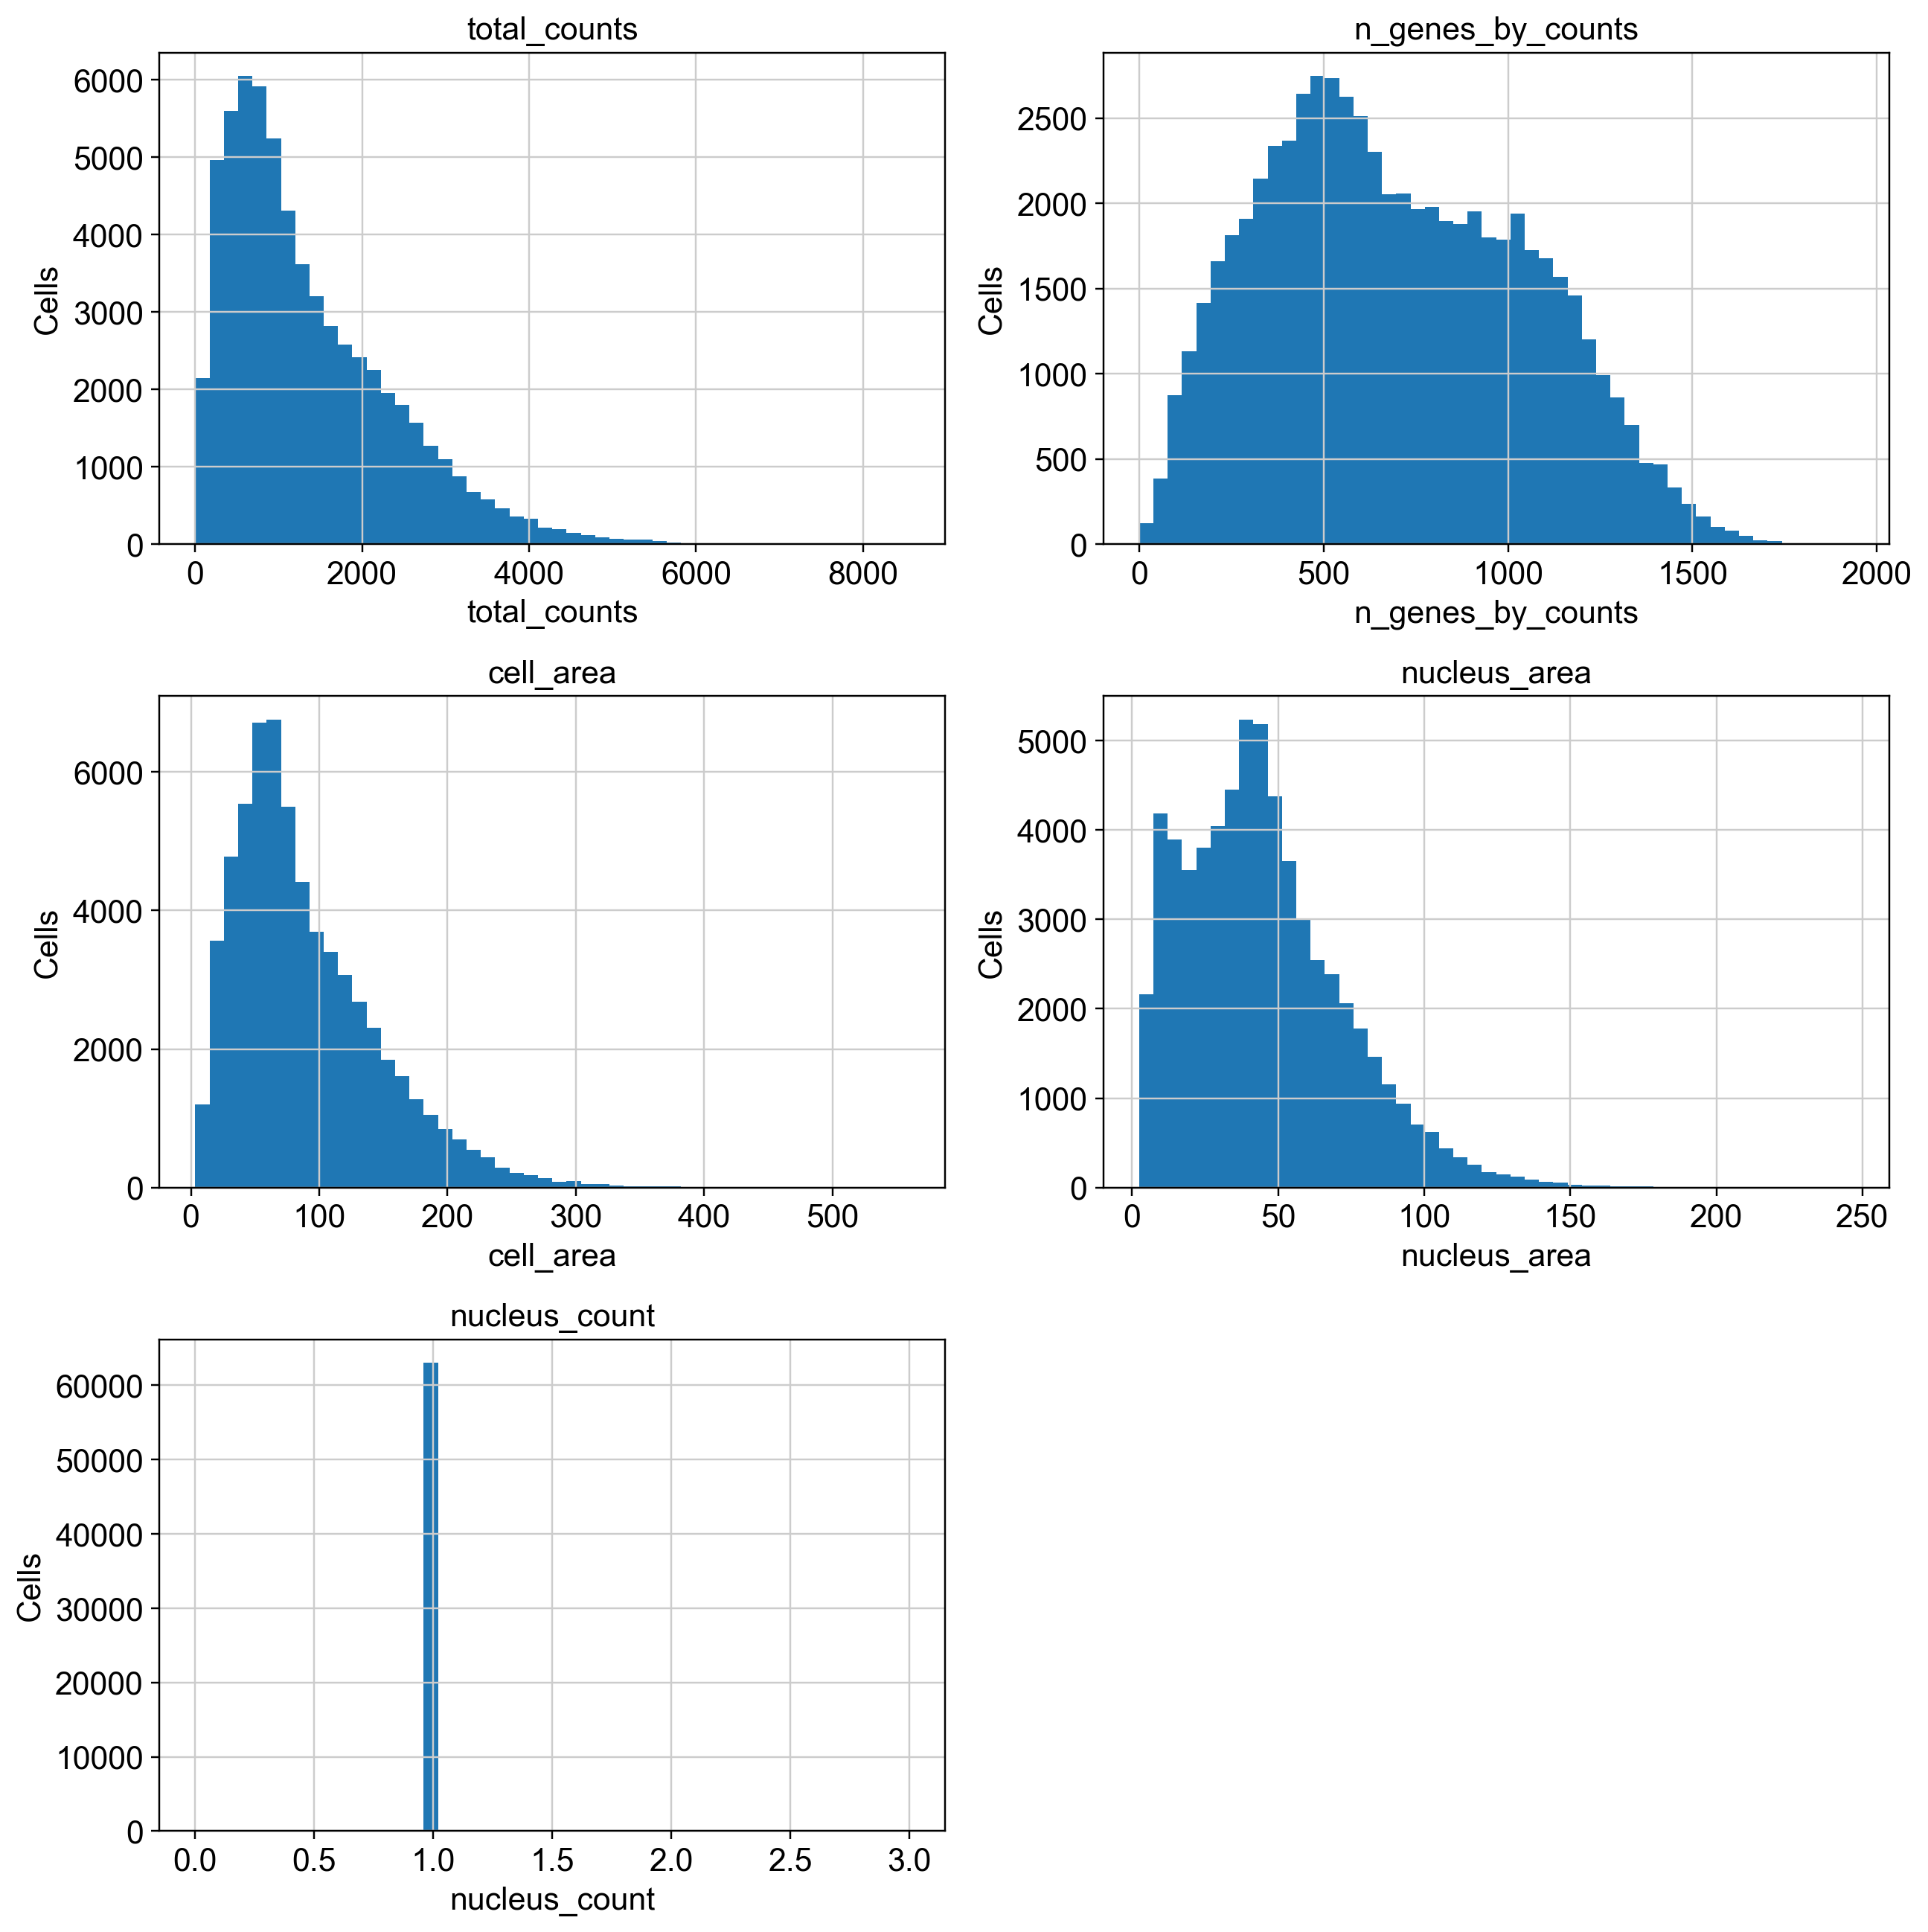

In [9]:
plot_cols = [
    col
    for col in ["total_counts", "n_genes_by_counts", "cell_area", "nucleus_area", "nucleus_count"]
    if col in adata.obs.columns
]

ncols = min(2, len(plot_cols))
nrows = int(np.ceil(len(plot_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, plot_cols):
    ax.hist(adata.obs[col].dropna(), bins=50)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Cells")

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()


## 10) Write extraction outputs

These are the main extraction artifacts to keep even if you skip downstream clustering.


In [10]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

adata.write_h5ad(RAW_H5AD_PATH)
adata.obs.to_csv(CELL_METADATA_PATH, index=True)
adata.var.to_csv(FEATURE_TABLE_PATH, index=True)
qc_summary.to_csv(QC_SUMMARY_PATH)

print(f"Wrote: {RAW_H5AD_PATH}")
print(f"Wrote: {CELL_METADATA_PATH}")
print(f"Wrote: {FEATURE_TABLE_PATH}")
print(f"Wrote: {QC_SUMMARY_PATH}")


Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k/mouseBrain5k_raw.h5ad
Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k/mouseBrain5k_cell_metadata.csv.gz
Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k/mouseBrain5k_features.csv.gz
Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k/mouseBrain5k_qc_summary.csv


## 11) Optional: inspect large auxiliary archives

- `analysis.zarr.zip` contains vendor-generated analysis results.
- `transcripts.zarr.zip` contains transcript-level records and is much larger, so it is not loaded by default here.


In [11]:
for path in [ANALYSIS_ZIP_PATH, TRANSCRIPTS_ZIP_PATH]:
    size_gb = path.stat().st_size / 1024**3 if path.exists() else np.nan
    print(f"{path.name}: exists={path.exists()} size_gb={size_gb:.2f}")


analysis.zarr.zip: exists=True size_gb=0.00
transcripts.zarr.zip: exists=True size_gb=3.44


## 12) Optional preprocessing scaffold

This keeps the notebook aligned with the rest of the repo, but it is deliberately separate from the extraction cells above.


In [12]:
ad_proc = adata.copy()

sc.pp.filter_cells(ad_proc, min_counts=MIN_COUNTS)
sc.pp.filter_cells(ad_proc, min_genes=MIN_GENES)
sc.pp.normalize_total(ad_proc, target_sum=TARGET_SUM)
sc.pp.log1p(ad_proc)

print(ad_proc)


filtered out 32 cells that have less than 15 counts
normalizing counts per cell
    finished (0:00:01)
AnnData object with n_obs × n_vars = 63141 × 5006
    obs: 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'sample_id', 'run_name', 'region_name', 'cell_id', 'n_genes_by_counts', 'total_counts', 'n_counts', 'n_genes'
    var: 'feature_id', 'feature_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'xenium_source', 'xenium_experiment', 'log1p'
    obsm: 'spatial'
    layers: 'counts'


In [39]:
ad_proc

AnnData object with n_obs × n_vars = 63141 × 5006
    obs: 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'sample_id', 'run_name', 'region_name', 'cell_id', 'n_genes_by_counts', 'total_counts', 'n_counts', 'n_genes', 'leiden_0.1', 'leiden_0.5', 'leiden_1.0'
    var: 'feature_id', 'feature_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'xenium_source', 'xenium_experiment', 'log1p', 'pca', 'neighbors', 'umap', 'sample_id_colors', 'leiden_0.1', 'leiden_0.1_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1.0', 'leiden_1.0_colors', 'rank_genes_groups'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## 13) Optional PCA, UMAP, and Leiden clustering


computing PCA
    with n_comps=30
    finished (0:00:10)


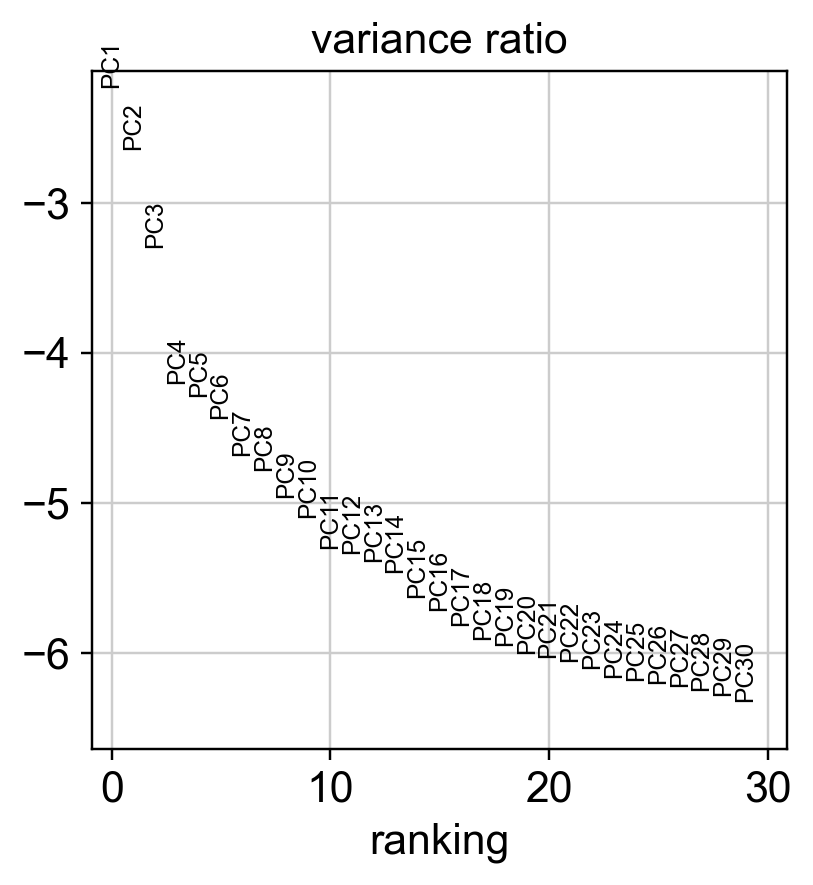

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:27)
computing UMAP
    finished (0:00:37)


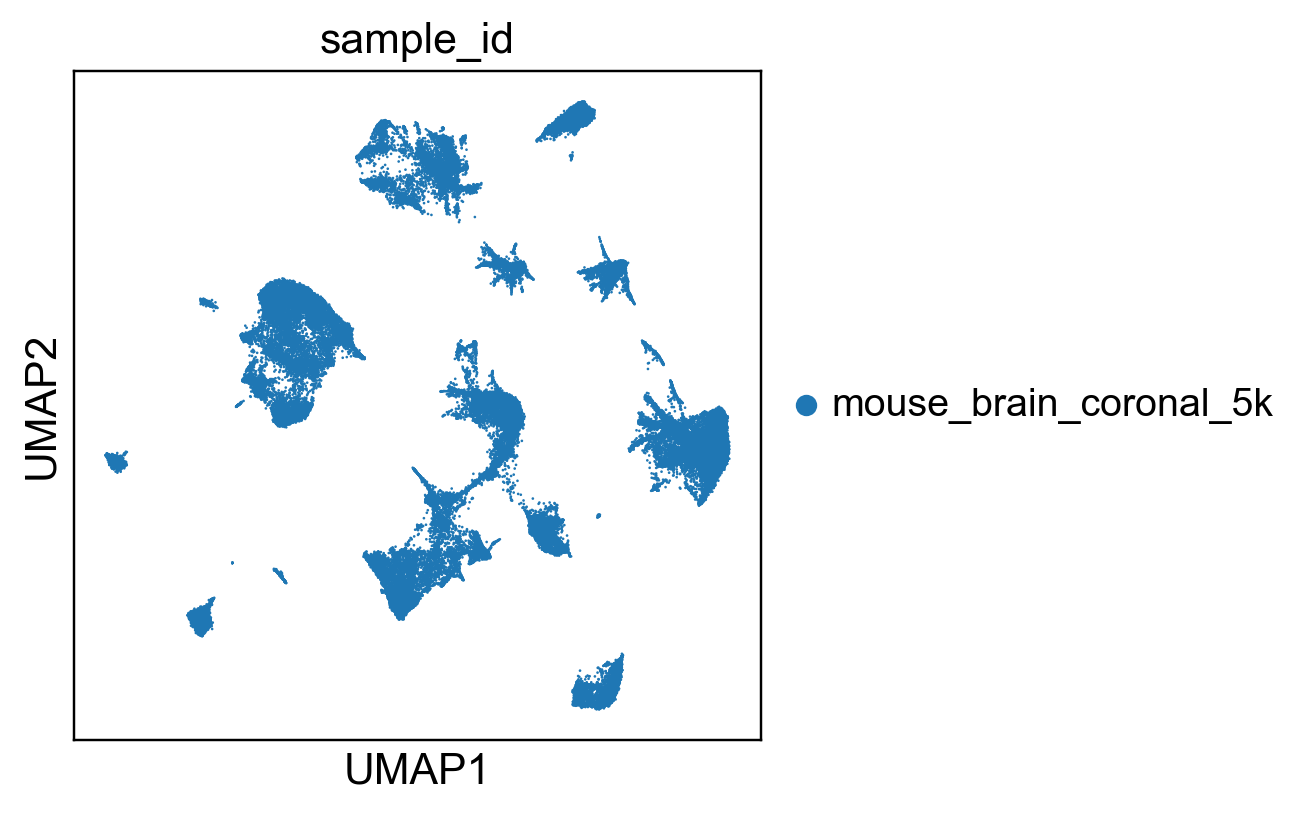

running Leiden clustering
    finished (0:00:05)


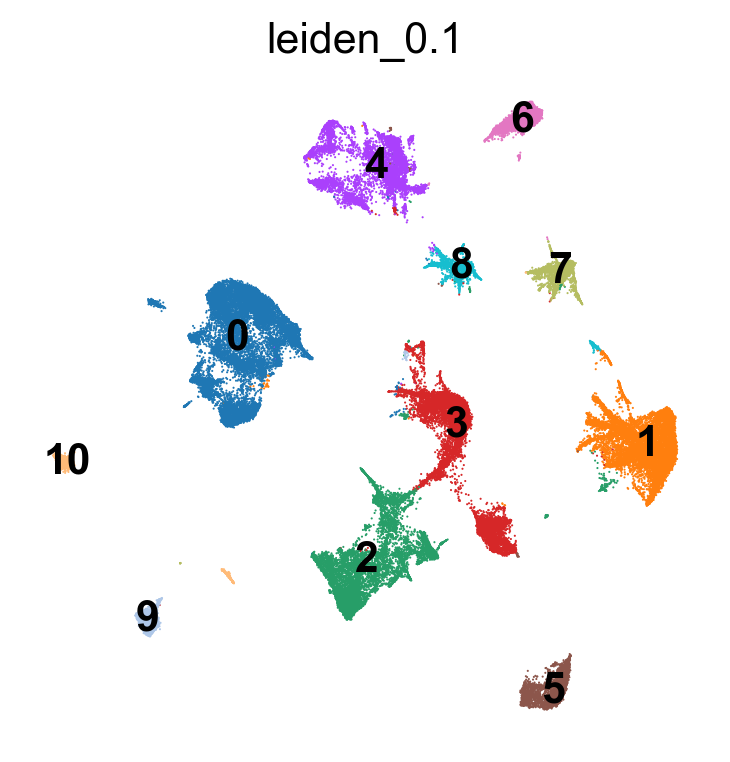

running Leiden clustering
    finished (0:00:09)


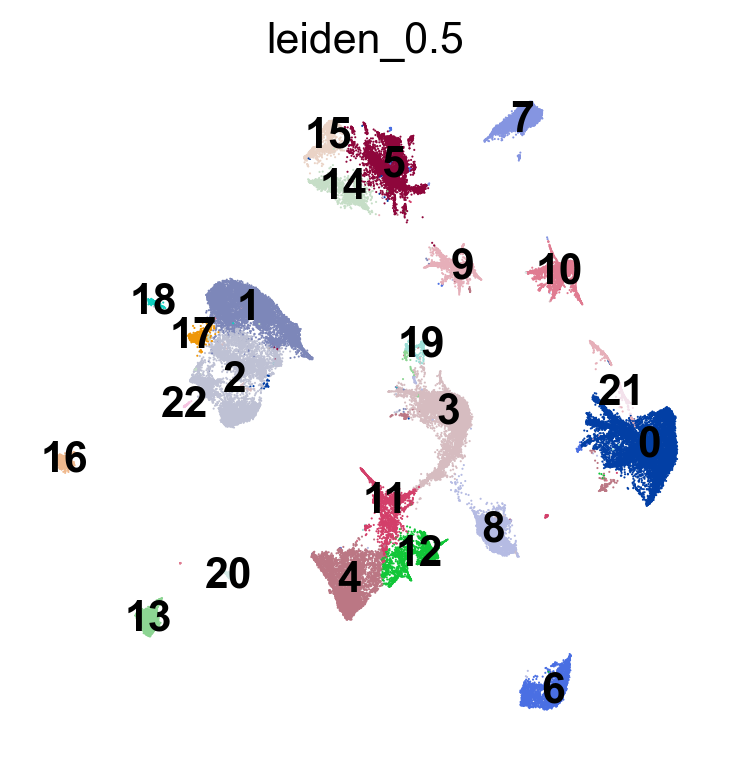

running Leiden clustering
    finished (0:00:07)


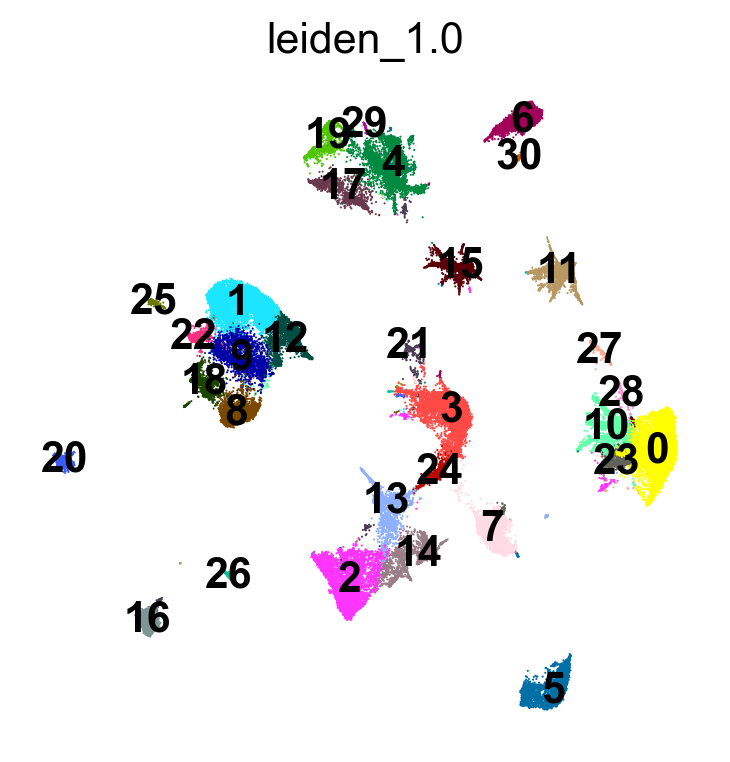

In [13]:
if ad_proc.n_obs < 3 or ad_proc.n_vars < 2:
    print("Need at least 3 cells and 2 genes after filtering before PCA/UMAP.")
else:
    n_pcs = min(N_PCS, ad_proc.n_obs - 1, ad_proc.n_vars - 1)

    if n_pcs < 2:
        print("Not enough dimensions remain after filtering for PCA/UMAP.")
    else:
        sc.tl.pca(ad_proc, n_comps=n_pcs)
        sc.pl.pca_variance_ratio(ad_proc, n_pcs=min(50, n_pcs), log=True)

        sc.pp.neighbors(ad_proc, n_neighbors=N_NEIGHBORS, n_pcs=n_pcs)
        sc.tl.umap(ad_proc, min_dist=0.1)
        sc.pl.umap(ad_proc, color=["sample_id"], s=3)

        for resolution in LEIDEN_RESOLUTIONS:
            key = f"leiden_{resolution}"
            sc.tl.leiden(ad_proc, resolution=resolution, key_added=key)
            sc.pl.umap(ad_proc, color=key, legend_loc="on data", frameon=False)


## 14) Optional marker export and processed checkpoint


In [14]:
cluster_key = "leiden_1.0"

if cluster_key not in ad_proc.obs.columns:
    print(f"{cluster_key} not present; skipping marker export.")
else:
    sc.tl.rank_genes_groups(ad_proc, groupby=cluster_key, method="t-test")
    markers = sc.get.rank_genes_groups_df(ad_proc, group=None)
    markers = markers.sort_values(["group", "logfoldchanges"], ascending=[True, False])
    markers.to_csv(MARKERS_PATH, index=False)
    print(f"Wrote: {MARKERS_PATH}")
    markers.head(30)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ad_proc.write_h5ad(PROCESSED_H5AD_PATH)
print(f"Wrote: {PROCESSED_H5AD_PATH}")


ranking genes
    finished (0:00:03)
Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k/mouseBrain5k_markers_leiden_1.0.csv
Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k/mouseBrain5k_processed.h5ad


In [15]:
import squidpy as sq
import cellcharter as cc

In [16]:
adata.obs['sample_id'] = adata.obs['sample_id'].astype('category')

In [18]:
sq.gr.spatial_neighbors(adata, library_key='sample_id', coord_type='generic', delaunay=True, percentile=99)


Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:07)


In [20]:
import scvi


In [21]:
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts", 
    batch_key='sample_id',
)

model = scvi.model.SCVI(adata)

In [23]:
import numpy as np

In [22]:
model.train(early_stopping=True, enable_progress_bar=True, max_epochs = 30 )


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 30/30: 100%|██████████| 30/30 [11:32<00:00, 23.87s/it, v_num=1, train_loss=1.83e+3]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [11:32<00:00, 23.07s/it, v_num=1, train_loss=1.83e+3]


In [25]:
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)

In [26]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key='sample_id')


100%|██████████| 4/4 [00:00<00:00, 20.46it/s]


In [27]:
# GMM components to try
# GMM components to try
gmm_components = [5, 10, 15,20]



In [28]:
from sklearn.mixture import GaussianMixture
import pandas as pd

X = adata.obsm['X_cellcharter']
gmm_results = []

for k in gmm_components:
    print(k)
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=0,
        n_init=3,
    )
    labels = gmm.fit_predict(X)
    key = f'CellCharter_{k}'
    adata.obs[key] = labels.astype(str)
    gmm_results.append({
        'k': k,
        'bic': gmm.bic(X),
        'aic': gmm.aic(X),
    })
    n_clusters = adata.obs[key].nunique()
    print(f'k={k}: {n_clusters} clusters')
    

5
k=5: 5 clusters
10
k=10: 10 clusters
15
k=15: 15 clusters
20
k=20: 20 clusters


In [29]:
import sys
sys.path.append("/Users/chrislangseth/work/karolinska_institutet/projects/BaloMS/")
from utils import spatial_utils

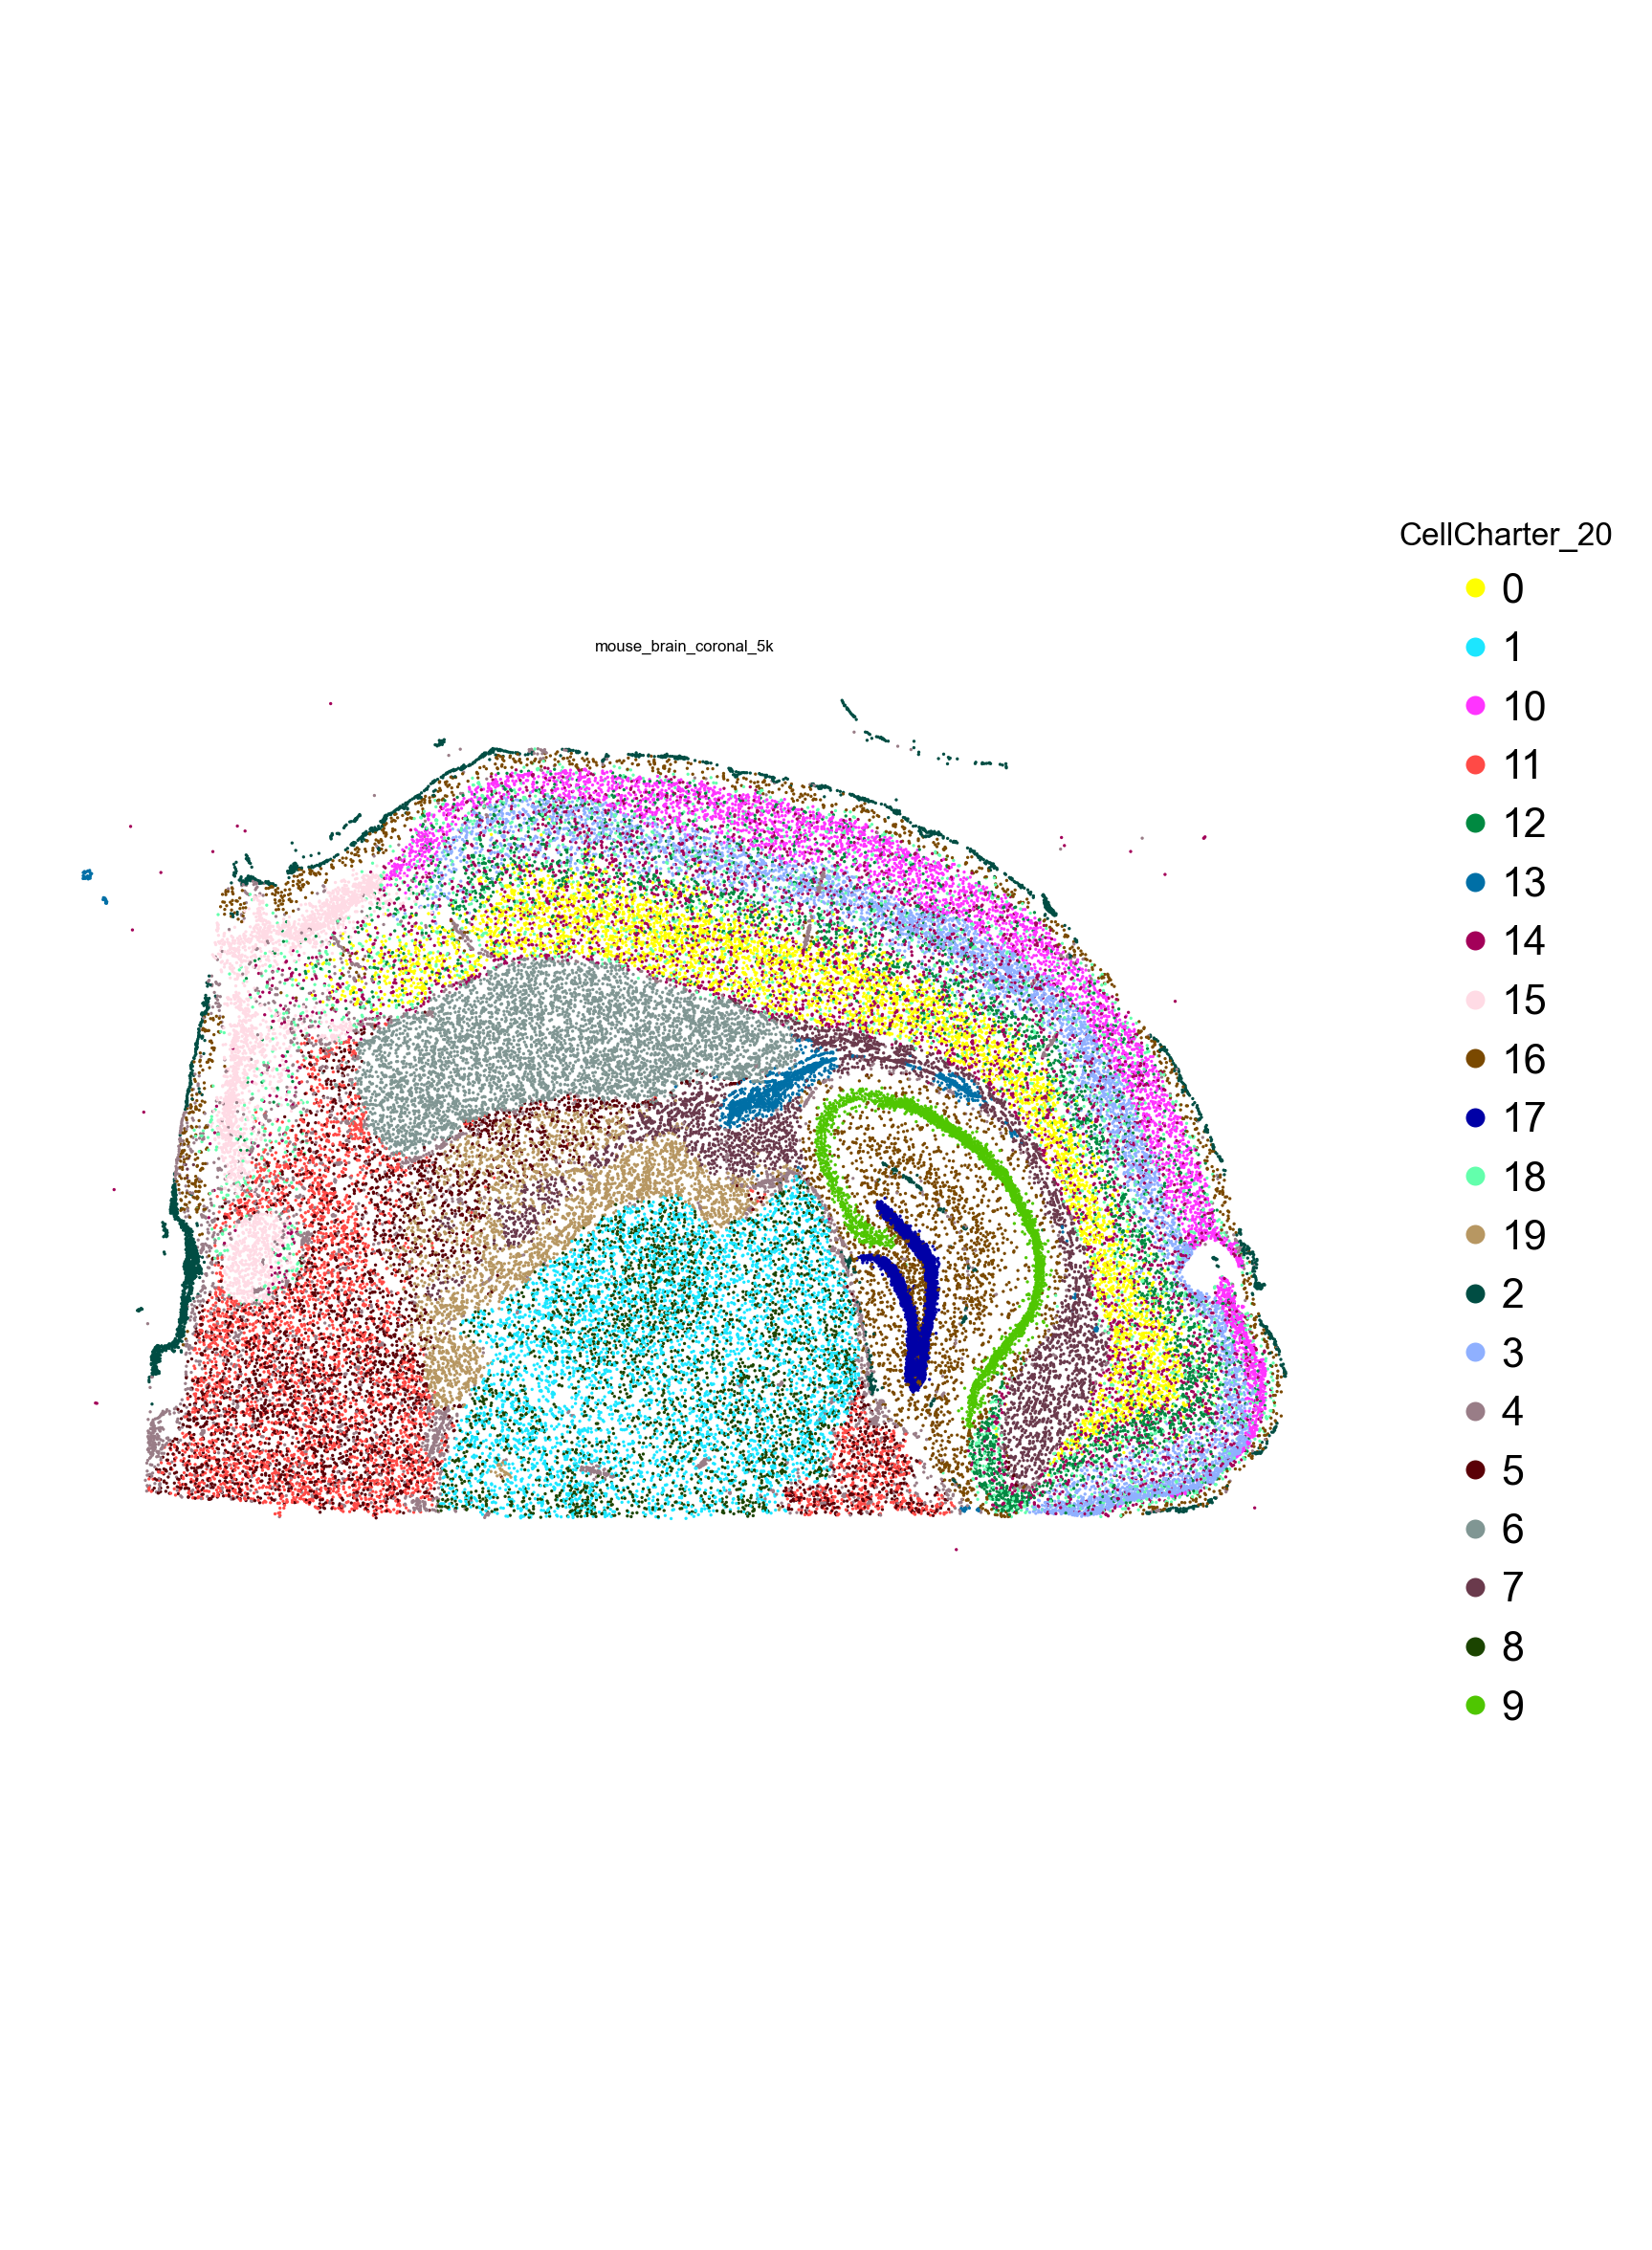

In [31]:
spatial_utils.plot_spatial_compact_fast(
    adata,
    color="CellCharter_20",
    groupby="sample_id",
    spot_size=1,
    cols=1,
    height=10,
    background="white",
    dpi=120,
)


In [44]:
adata = adata[adata.obs.index.isin(ad_proc.obs.index)]

In [46]:
adata.obs[['leiden_0.1', 'leiden_0.5', 'leiden_1.0']] = ad_proc.obs[['leiden_0.1', 'leiden_0.5', 'leiden_1.0']]

In [ ]:
adata.obs[['leiden_0.1', 'leiden_0.5', 'leiden_1.0']]

,leiden_0.1,leiden_0.5,leiden_1.0
cell_id,,,
45075,2,11,13
77175,2,11,13
187535,2,11,13
232071,2,11,13
298314,2,11,13
...,...,...,...
3904102053,2,12,14
3904106990,3,8,7
3904242929,2,4,2


In [54]:
ad_proc.obs[['CellCharter_5', 'CellCharter_10', 'CellCharter_15', 'CellCharter_20']] = adata.obs[['CellCharter_5', 'CellCharter_10', 'CellCharter_15', 'CellCharter_20']]

AnnData object with n_obs × n_vars = 63141 × 5006
    obs: 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'sample_id', 'run_name', 'region_name', 'cell_id', 'n_genes_by_counts', 'total_counts', '_scvi_batch', '_scvi_labels', 'CellCharter_5', 'CellCharter_10', 'CellCharter_15', 'CellCharter_20', 'leiden_0.1', 'leiden_0.5', 'leiden_1.0'
    var: 'feature_id', 'feature_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'xenium_source', 'xenium_experiment', 'spatial_neighbors', '_scvi_uuid', '_scvi_manager_uuid', 'CellCharter_5_colors', 'CellCharter_20_colors'
    obsm: 'spatial', 'X_scVI', 'X_cellcharter'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [55]:
ad_proc.write_h5ad('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/mouseBrain5k/mouseBrain5k_cellcharter.h5ad')

In [57]:
ad_proc.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 43994652 stored elements and shape (63141, 5006)>